In [1]:
%load_ext autoreload
%autoreload 2

### Setup

In [2]:
import os, sys
sys.path.append(os.path.dirname(os.getcwd())) # Add the parent directory to sys.path
sys.path.append('/Users/dhei/ai2/new-evals/olmo-repos/olmo/scripts') # Add the parent directory to sys.path

import pandas as pd
import numpy as np

from utils import DATA_DIR
from dataloader import get_nd_array, get_slice

from download.weka import pull_predictions_from_weka

In [3]:
pull_predictions_from_weka("aws")

File already exists and matches size: /Users/dhei/ai2/new-evals/analysis/data/all_aws_predictions.parquet


In [4]:
df = pd.read_parquet(f'{DATA_DIR}/all_aws_predictions.parquet')

In [5]:
MODELS = df.index.get_level_values('model').unique().to_list()
TASKS  = df.index.get_level_values('task').unique().to_list()
MIXES  = df.index.get_level_values('mix').unique().to_list()
STEPS  = df.index.get_level_values('step').unique().to_list()

TASKS = [t for t in TASKS if 'mmlu' not in t]
TASKS = sorted(TASKS)

print(MODELS)
print(TASKS)
print(MIXES)
# print(STEPS)

['peteish-moreeval-190M-2xC', 'peteish-moreeval-rerun-370M-1xC', 'peteish-moreeval-190M-0.5xC', 'peteish-moreeval-370M-0.5xC', 'peteish-moreeval-1B-0.5xC', 'peteish-moreeval-760M-2xC', 'peteish-moreeval-1B-2xC', 'peteish-moreeval-rerun-760M-1xC', 'peteish-moreeval-370M-2xC', 'peteish-moreeval-1B-5xC', 'peteish-moreeval-rerun-190M-1xC', 'peteish-moreeval-3B-0.5xC', 'peteish-moreeval-760M-0.5xC', 'peteish-moreeval-rerun-1B-1xC', 'OLMo-1B-hf', 'OLMo-7B-0724-hf', 'DCLM-baseline-1B-5xC', 'no_code-1B-5xC', 'no_reddit-1B-5xC', 'peteish-moreeval-370M-10xC', 'falcon-1B-5xC', 'peteish-moreeval-3B-5xC', 'peteish-moreeval-1B-10xC', 'no_math_no_code-1B-5xC', 'c4-1B-5xC', 'redpajama-1B-5xC', 'peteish13-highlr', 'peteish7', 'phi-1_5', 'dolma17-75p-DCLM-baseline-25p-1B-5xC', 'peteish-moreeval-760M-10xC', 'peteish-moreeval-3B-10xC', 'peteish-moreeval-rerun-3B-1xC', 'peteish-moreeval-3B-2xC', 'peteish-moreeval-190M-5xC', 'peteish-moreeval-760M-5xC', 'peteish-moreeval-370M-5xC', 'peteish-moreeval-190M-10

In [6]:
# models, scores = get_nd_array(df, 'model', 'acc_per_char', task='arc_challenge:distractors')
# models, scores = get_nd_array(df, ['model', 'mix'], 'acc_per_char', task='arc_challenge:distractors')

### Measure 1: Predictability (Rel Error @ 7B)

In [7]:
import matplotlib.pyplot as plt

# https://arxiv.org/pdf/2412.04403#page=3.57
LADDER_MODELS = [model for model in MODELS if 'peteish-moreeval' in model]

# For the paper, we did not use 3B or 0.5xC models
akshita_ladder_models = [
    model for model in LADDER_MODELS if "3B" not in model and "0.5xC" not in model
]

In [ ]:
from ladder import get_ladder_data

# Example of grabbing ladder data
data_by_name = get_ladder_data(
    df, task_name="arc_challenge", train_models=LADDER_MODELS, eval_models=["peteish7"]
)

In [9]:
# Sanity check for task results
task_name = 'arc_easy:enlarge'
model = 'peteish7'
m2, bpb  = get_nd_array(df, 'model', 'logits_per_byte', model=model, task=task_name, step='max')
data_by_name = get_ladder_data(df, task_name, LADDER_MODELS, ['peteish_7'])

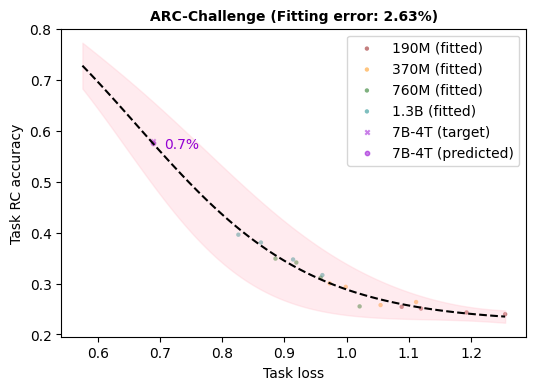

In [10]:
from ladder import run_ladder_step_2

# python scripts/scaling/step2.py -k v2_main -c scripts/scaling/step2.json -o figure/peteish-moreeval/step2_main.pdf --skip_perc 1

fig, axes = plt.subplots(1, 1, figsize=(6, 4), squeeze=False)
y, y_pred, rel_error, delta_error = run_ladder_step_2(
    df,
    task_name="arc_challenge",
    train_models=akshita_ladder_models,
    eval_models=["peteish7"],
    ax=axes[0][0],
)

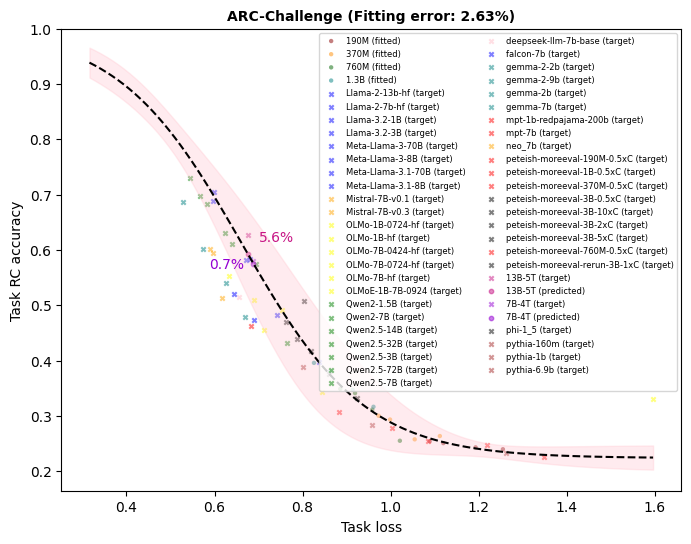

In [11]:
from utils.constants_models import MODEL_LIST_MIXES

MODEL_LIST_MIXES = [model.split("/")[-1] for model in MODEL_LIST_MIXES]
BROKEN_MODELS = []
all_models = sorted([model for model in MODELS if model not in MODEL_LIST_MIXES + BROKEN_MODELS + akshita_ladder_models])

fig, axes = plt.subplots(1, 1, figsize=(8, 6), squeeze=False)
y, y_pred, rel_error, delta_error = run_ladder_step_2(
    df,
    task_name="arc_challenge",
    train_models=akshita_ladder_models,
    eval_models=all_models,
    ax=axes[0][0],
)
_ = axes[0][0].legend(fontsize=6, ncol=2)

In [12]:
num_rows, num_cols = len(TASKS), 1
fig, axes = plt.subplots(num_rows, num_cols, figsize=(6 * num_cols, 4 * num_rows), squeeze=False)

fitting_results = pd.DataFrame(index=['rel_error'], columns=TASKS)

for i, task in enumerate(TASKS):
    ax: plt.Axes = axes[i, 0]

    try:
        y, y_pred, rel_error, delta_error = run_ladder_step_2(
            df, 
            task_name=task, 
            train_models=akshita_ladder_models, 
            eval_models=['peteish7'], 
            ax=ax
        )

        ax.set_title(task)
        ax.legend(fontsize=4, ncol=2)

        fitting_results.loc['rel_error', task] = abs(rel_error)
    except Exception as e:
        print(f'{task} failed: {e}')
        continue

fig.tight_layout()

plt.close(fig)

In [13]:
from table import display_task_variants

print(f'Relative error predicting performance of 7B using only final checkpoints of ladder models up to 1B-10xC:')
display_task_variants(fitting_results, key='rel_error', inverse=True, ascending=True)

Relative error predicting performance of 7B using only final checkpoints of ladder models up to 1B-10xC:


Variant,default rc,distractors,enlarge,para
Task,,,,
arc_challenge,0.7%,0.6% (-0.1%),7.0% (+6.3%),14.9% (+14.3%)
piqa,0.8%,--,--,1.9% (+1.2%)
hellaswag,0.9%,--,--,2.3% (+1.4%)
arc_easy,2.9%,0.7% (-2.2%),6.5% (+3.6%),2.8% (-0.1%)
csqa,4.8%,--,--,2.5% (-2.2%)
socialiqa,5.4%,--,--,3.9% (-1.4%)
openbookqa,8.0%,--,--,13.8% (+5.7%)
boolq,14.0%,--,--,2.3% (-11.7%)
winogrande,14.8%,--,--,13.3% (-1.5%)


### Measure 2: Seperability (% sig @ 1B)

In [14]:
from IPython.display import HTML, display

def display_image(path, max_width='1000px'):
    image_html = HTML(f'''
    <div style="background-color:white; max-width: {max_width};">
        <img src="{path}" style="background-color:white; ">
    </div>
    ''')
    display(image_html)

print('Explanation of a paired permutation test:')
os.chdir('/Users/dhei/ai2/new-evals/analysis/notebooks')
display_image('assets/paired-permutation-test.png')

Explanation of a paired permutation test:


In [15]:
from stats import compute_significance
from utils.constants_models import MODEL_LIST_MIXES

MODEL_LIST_MIXES = [model.split('/')[-1] for model in MODEL_LIST_MIXES]

Computing pairwise comparisons: 100%|██████████| 1/1 [00:00<00:00,  4.75it/s]


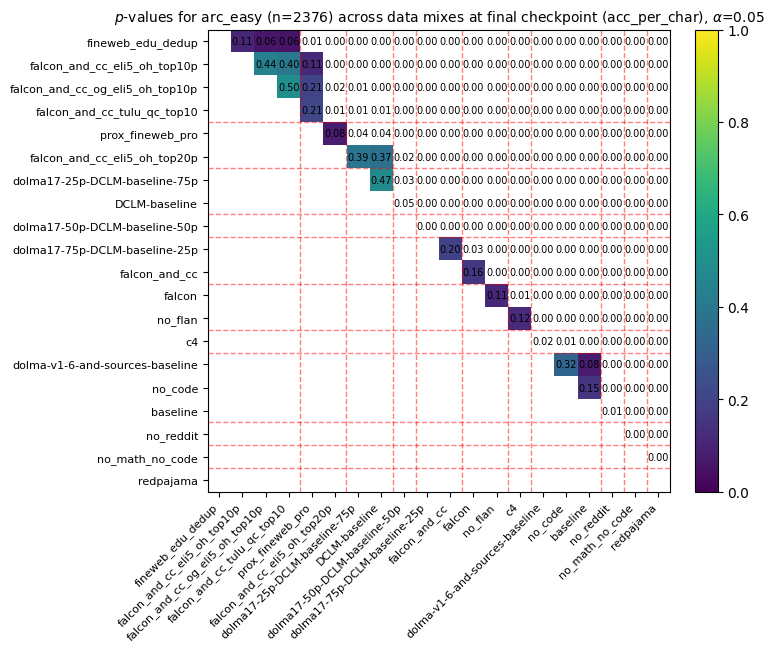

In [16]:
fig, axes = plt.subplots(1, 1, figsize=(8, 6), squeeze=False)

sig_results, _, ax = compute_significance(
    df, 
    models=MODEL_LIST_MIXES, 
    metric='acc_per_char', 
    tasks=['arc_easy'], 
    do_plot=axes[0][0]
)

In [17]:
sig_results, _, _ = compute_significance(
    df, 
    models=MODEL_LIST_MIXES, 
    metric='acc_per_char', 
    # tasks='arc_easy',
    tasks=TASKS,
    do_plot=False
)

Computing pairwise comparisons: 100%|██████████| 22/22 [00:04<00:00,  4.65it/s]


In [18]:
from table import display_task_variants

print('% of significant comparisons for 1B-5xC models on 20 data mixes:')
display_task_variants(sig_results, key='perc_sig')

% of significant comparisons for 1B-5xC models on 20 data mixes:


Variant,default rc,distractors,enlarge,para
Task,,,,
arc_easy,89.5%,91.1% (+1.6%),92.6% (+3.2%),84.7% (-4.7%)
hellaswag,87.4%,--,--,79.5% (-7.9%)
csqa,79.5%,--,--,51.6% (-27.9%)
arc_challenge,73.7%,75.3% (+1.6%),89.5% (+15.8%),76.3% (+2.6%)
boolq,70.5%,--,--,78.9% (+8.4%)
socialiqa,55.3%,--,--,41.6% (-13.7%)
openbookqa,48.9%,--,--,48.9% (+0.0%)
piqa,33.2%,--,--,28.4% (-4.7%)
winogrande,23.7%,--,--,23.2% (-0.5%)


### Measure 3: Smoothness (Total Variation @ 1B)

In [19]:
from stats import calc_total_variation

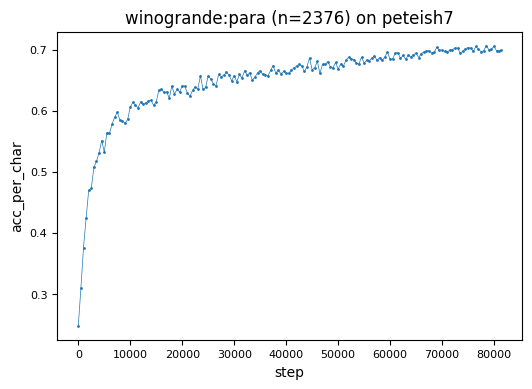

In [20]:
from plot import plot_training

fig, axes = plt.subplots(1, 1, figsize=(6, 4), squeeze=False)

step, scores = get_nd_array(df, 'step', 'acc_per_char', model='peteish-moreeval-1B-5xC', task='arc_easy')
acc = scores.mean(axis=1)

_ = plot_training(
    ax=axes[0][0], 
    x=step, y=acc, 
    xlabel='step', ylabel='acc_per_char', 
    title=f'{task} (n={scores.shape[1]}) on {model}'
)

In [21]:
tv_results = pd.DataFrame(index=['total_variation'], columns=TASKS)

for task in TASKS:
    step, scores = get_nd_array(df, 'step', 'acc_per_char', model='peteish-moreeval-1B-5xC', task=task) # (step, instance)

    if len(scores) <= 1: continue

    acc = scores.mean(axis=1) # (step)
    
    tv_results.loc['total_variation', task] = calc_total_variation(acc, improvement=True) * 100

In [22]:
print(f'TV-I for {scores.shape[0]} intermediate checkpoints on 1B 5xC peteish ladder (OLMoE mix):')
display_task_variants(tv_results, key='total_variation', as_prct=False, inverse=True, ascending=True)

TV-I for 164 intermediate checkpoints on 1B 5xC peteish ladder (OLMoE mix):


Variant,default rc,distractors,enlarge,para
Task,,,,
hellaswag,0.17,--,--,0.18 (+0.01)
piqa,0.37,--,--,0.38 (+0.01)
socialiqa,0.50,--,--,0.57 (+0.07)
arc_easy,0.53,0.59 (+0.06),0.58 (+0.05),0.43 (-0.10)
csqa,0.56,--,--,0.67 (+0.11)
winogrande,0.62,--,--,0.67 (+0.05)
arc_challenge,0.67,0.67 (+0.00),0.53 (-0.15),0.72 (+0.05)
openbookqa,0.93,--,--,1.03 (+0.10)
boolq,3.56,--,--,1.13 (-2.43)


### All 3 Measures

In [23]:
print(f'Relative error predicting performance of 7B using only final checkpoints of ladder models up to 1B-10xC:')
display_task_variants(fitting_results, key='rel_error', inverse=True, ascending=True)

print('% of significant comparisons for 1B-5xC models on 20 data mixes:')
display_task_variants(sig_results, key='perc_sig')

print(f'TV-I for intermediate checkpoints on 1B 5xC peteish ladder (OLMoE mix):')
display_task_variants(tv_results, key='total_variation', as_prct=False, inverse=True, ascending=True)

Relative error predicting performance of 7B using only final checkpoints of ladder models up to 1B-10xC:


Variant,default rc,distractors,enlarge,para
Task,,,,
arc_challenge,0.7%,0.6% (-0.1%),7.0% (+6.3%),14.9% (+14.3%)
piqa,0.8%,--,--,1.9% (+1.2%)
hellaswag,0.9%,--,--,2.3% (+1.4%)
arc_easy,2.9%,0.7% (-2.2%),6.5% (+3.6%),2.8% (-0.1%)
csqa,4.8%,--,--,2.5% (-2.2%)
socialiqa,5.4%,--,--,3.9% (-1.4%)
openbookqa,8.0%,--,--,13.8% (+5.7%)
boolq,14.0%,--,--,2.3% (-11.7%)
winogrande,14.8%,--,--,13.3% (-1.5%)


% of significant comparisons for 1B-5xC models on 20 data mixes:


Variant,default rc,distractors,enlarge,para
Task,,,,
arc_easy,89.5%,91.1% (+1.6%),92.6% (+3.2%),84.7% (-4.7%)
hellaswag,87.4%,--,--,79.5% (-7.9%)
csqa,79.5%,--,--,51.6% (-27.9%)
arc_challenge,73.7%,75.3% (+1.6%),89.5% (+15.8%),76.3% (+2.6%)
boolq,70.5%,--,--,78.9% (+8.4%)
socialiqa,55.3%,--,--,41.6% (-13.7%)
openbookqa,48.9%,--,--,48.9% (+0.0%)
piqa,33.2%,--,--,28.4% (-4.7%)
winogrande,23.7%,--,--,23.2% (-0.5%)


TV-I for intermediate checkpoints on 1B 5xC peteish ladder (OLMoE mix):


Variant,default rc,distractors,enlarge,para
Task,,,,
hellaswag,0.17,--,--,0.18 (+0.01)
piqa,0.37,--,--,0.38 (+0.01)
socialiqa,0.50,--,--,0.57 (+0.07)
arc_easy,0.53,0.59 (+0.06),0.58 (+0.05),0.43 (-0.10)
csqa,0.56,--,--,0.67 (+0.11)
winogrande,0.62,--,--,0.67 (+0.05)
arc_challenge,0.67,0.67 (+0.00),0.53 (-0.15),0.72 (+0.05)
openbookqa,0.93,--,--,1.03 (+0.10)
boolq,3.56,--,--,1.13 (-2.43)


Computing pairwise comparisons: 100%|██████████| 1/1 [00:00<00:00,  4.23it/s]


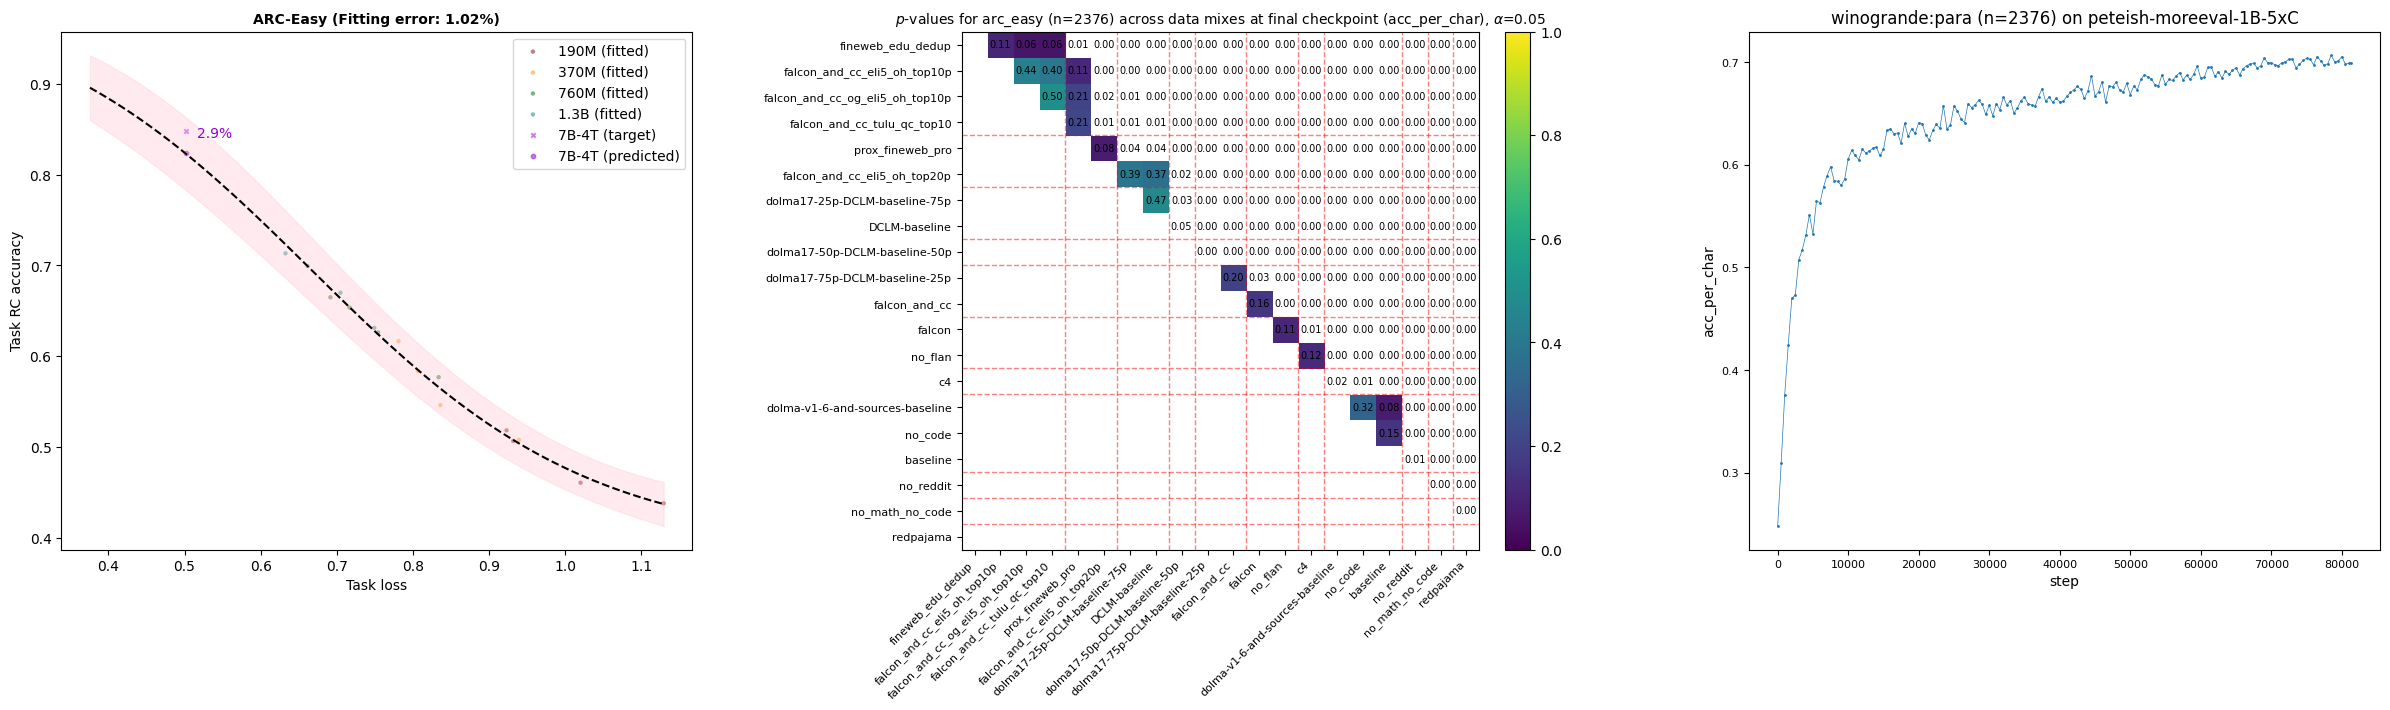

In [24]:
def plot_all_measures(task_name):
    fig, axes = plt.subplots(1, 3, figsize=(8*3, 7), squeeze=False)

    # Measure 1: Predictability
    y, y_pred, rel_error, delta_error = run_ladder_step_2(
        df,
        task_name=task_name,
        train_models=akshita_ladder_models,
        # eval_models=all_models,
        eval_models=['peteish7'],
        ax=axes[0][0],
    )
    # _ = axes[0][0].legend(fontsize=6, ncol=2)

    # Measure 2: Seperability
    sig_results, _, ax = compute_significance(
        df, 
        models=MODEL_LIST_MIXES, 
        metric='acc_per_char', 
        tasks=[task_name], 
        do_plot=axes[0][1]
    )

    # Measure 3: Smoothness
    model = 'peteish-moreeval-1B-5xC'

    step, scores = get_nd_array(
        df, 
        col='step', 
        metric='acc_per_char',
        model=model, 
        task=task_name
    )
    acc = scores.mean(axis=1)

    _ = plot_training(
        ax=axes[0][2], 
        x=step, y=acc, 
        xlabel='step', ylabel='acc_per_char', 
        title=f'{task} (n={scores.shape[1]}) on {model}'
    )

    fig.tight_layout()

    return fig

_ = plot_all_measures('arc_easy')

Computing pairwise comparisons: 100%|██████████| 1/1 [00:00<00:00,  5.55it/s]


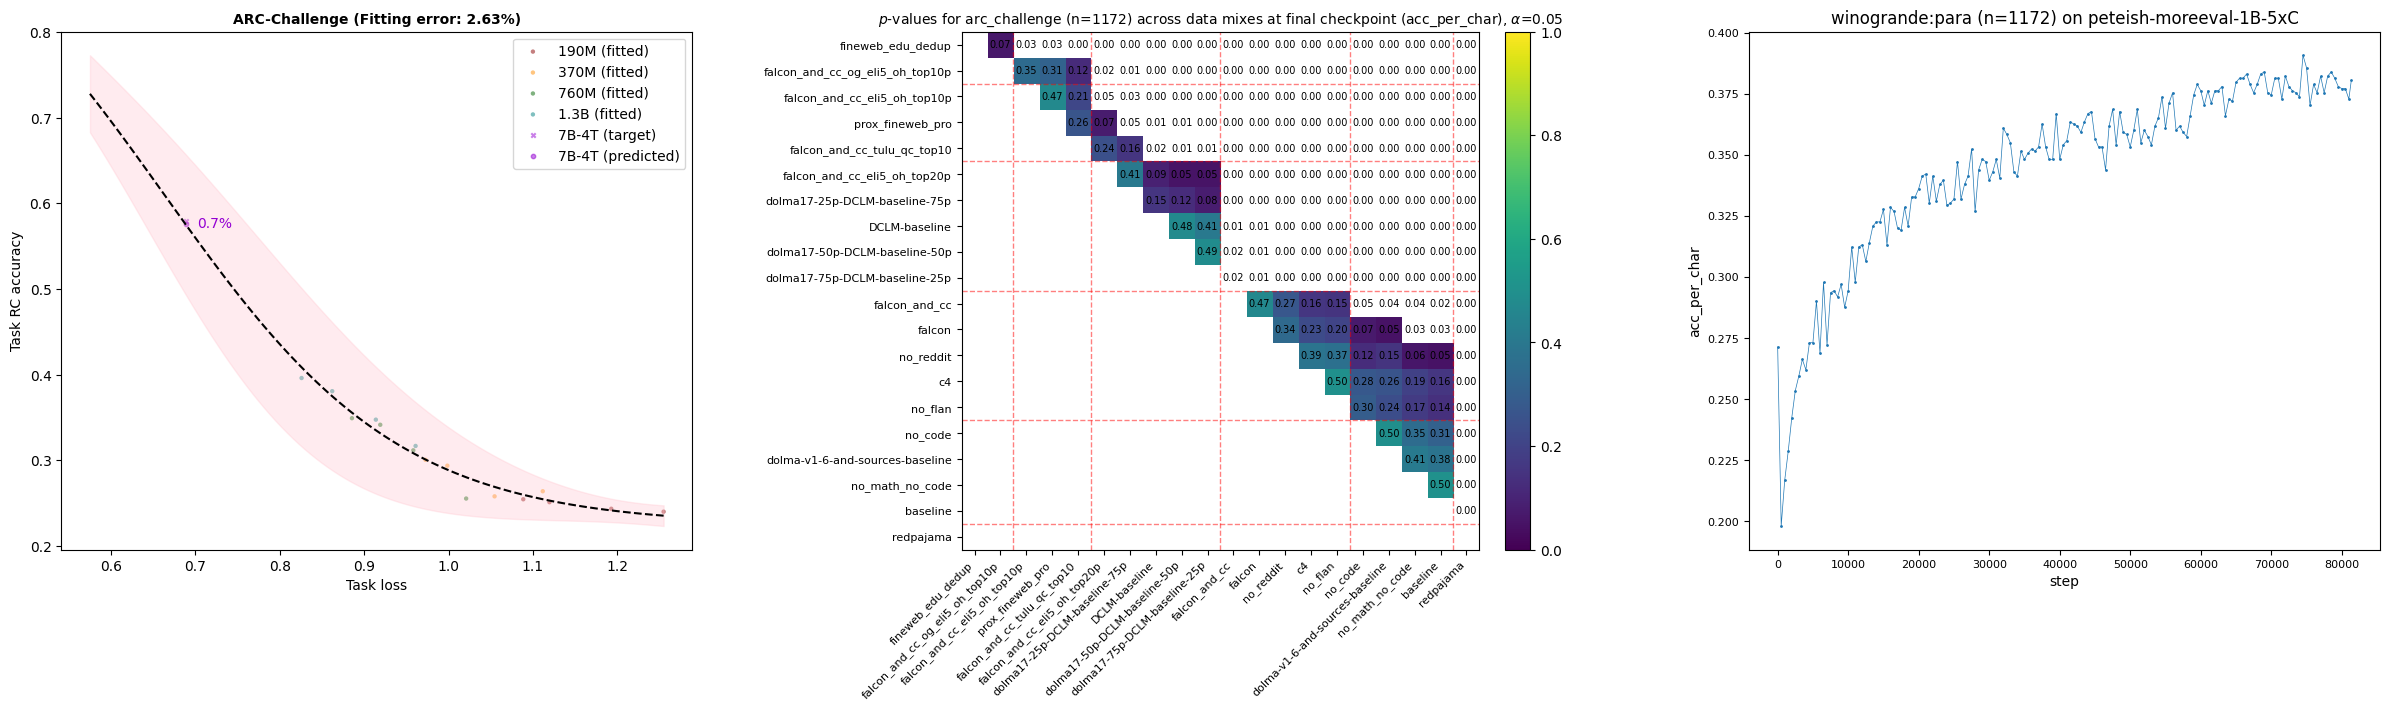

In [25]:
_ = plot_all_measures('arc_challenge')

### Benchmark Transformations

Computing pairwise comparisons: 100%|██████████| 1/1 [00:00<00:00,  5.02it/s]


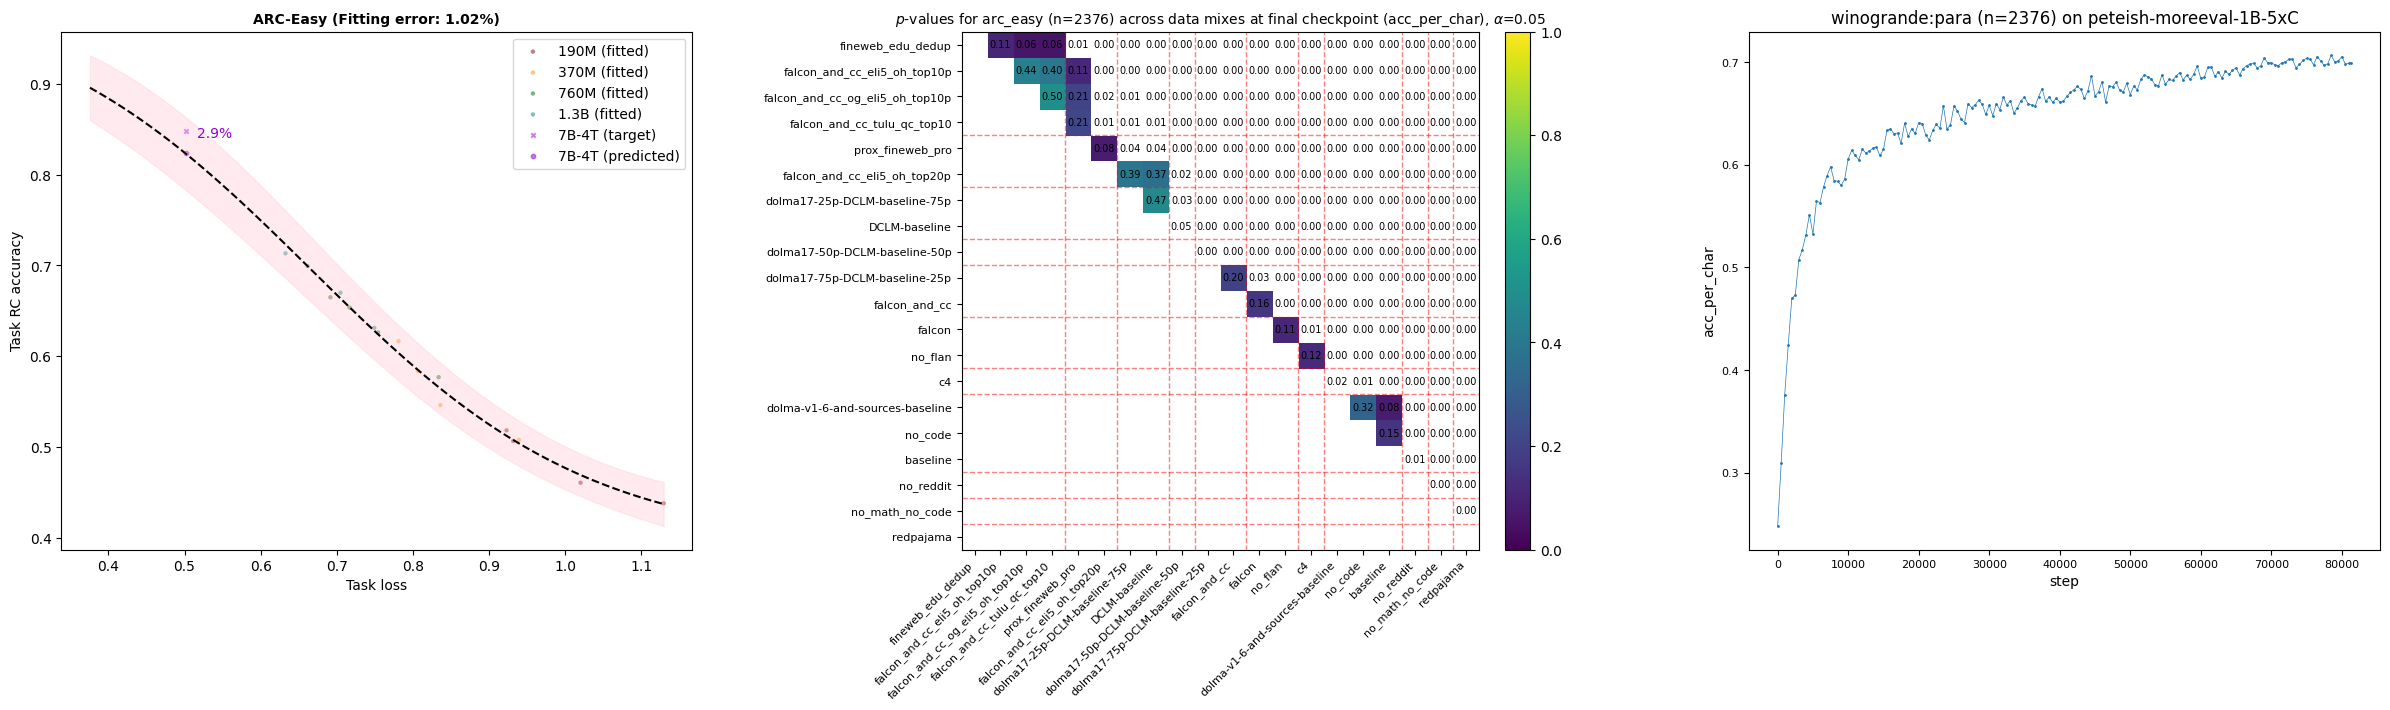

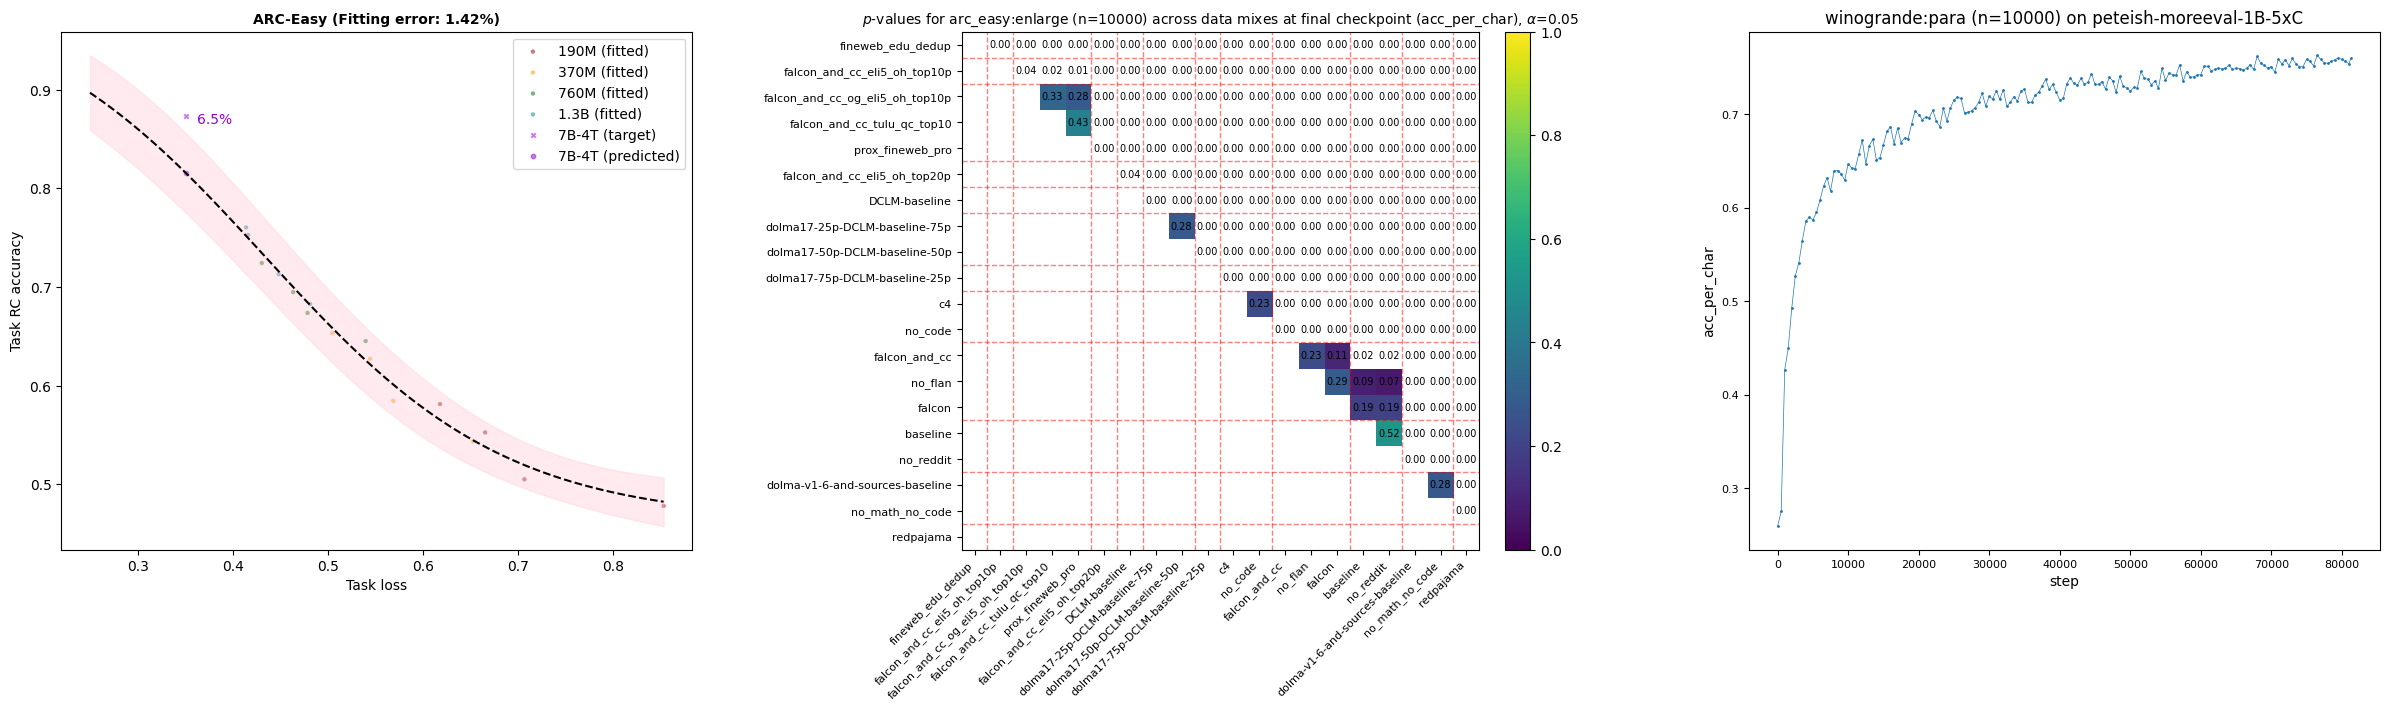

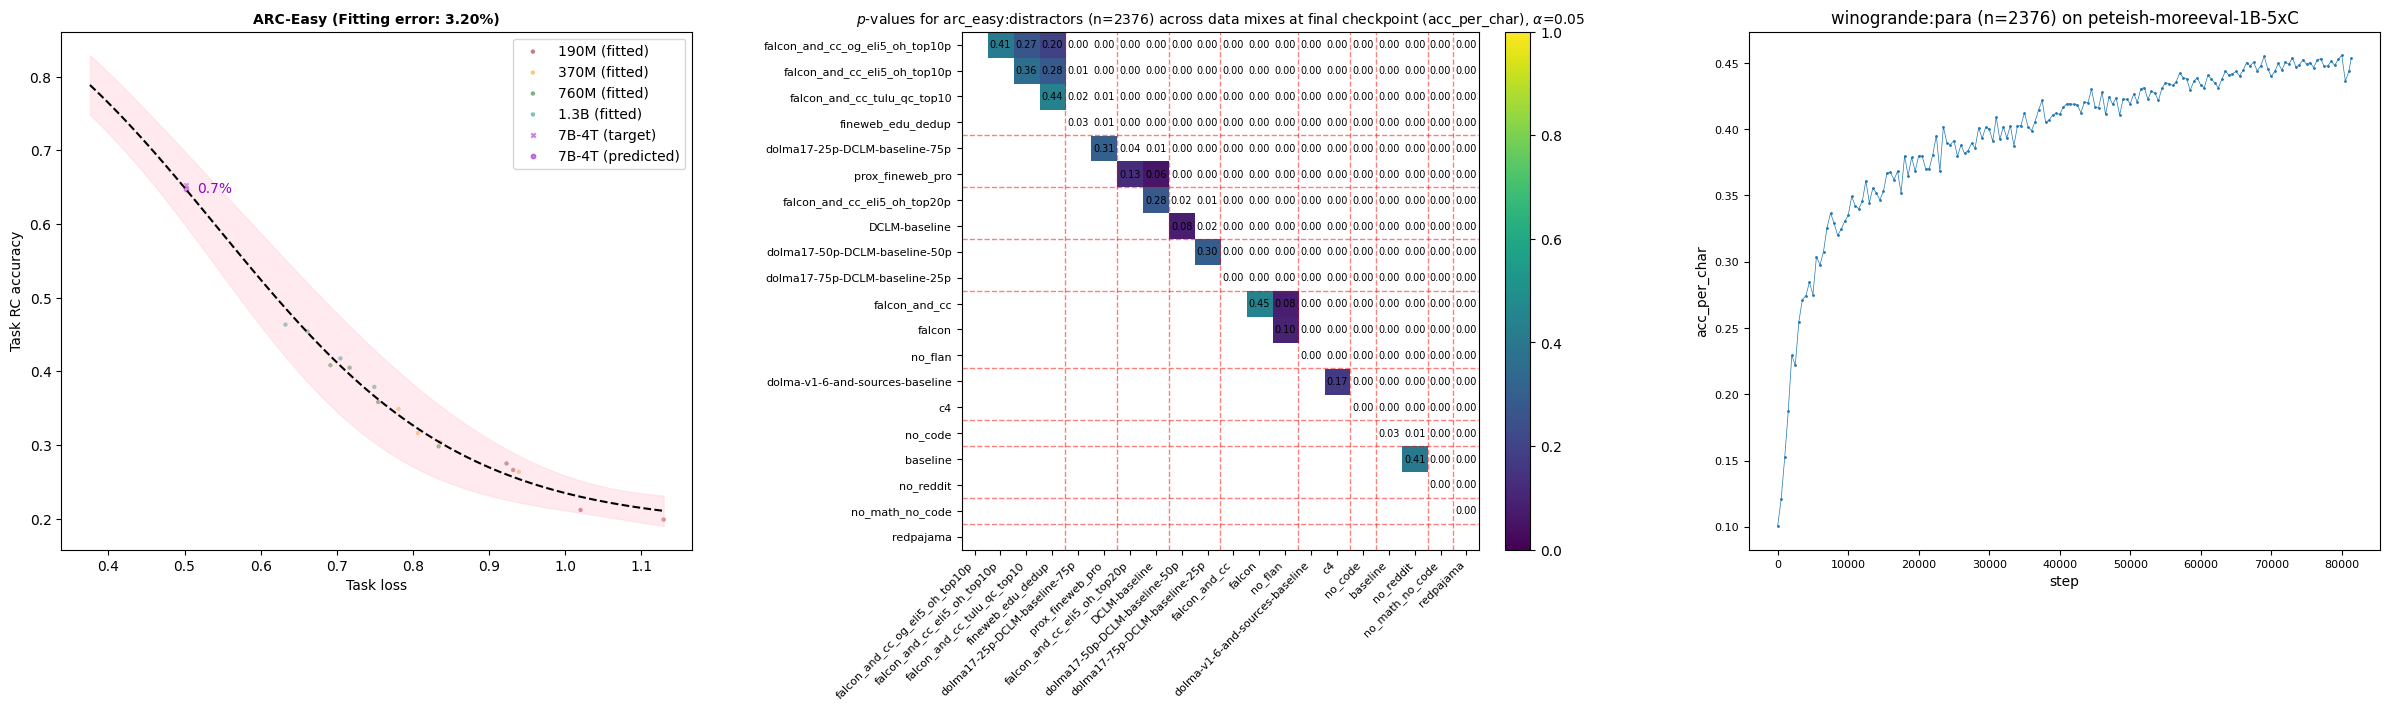

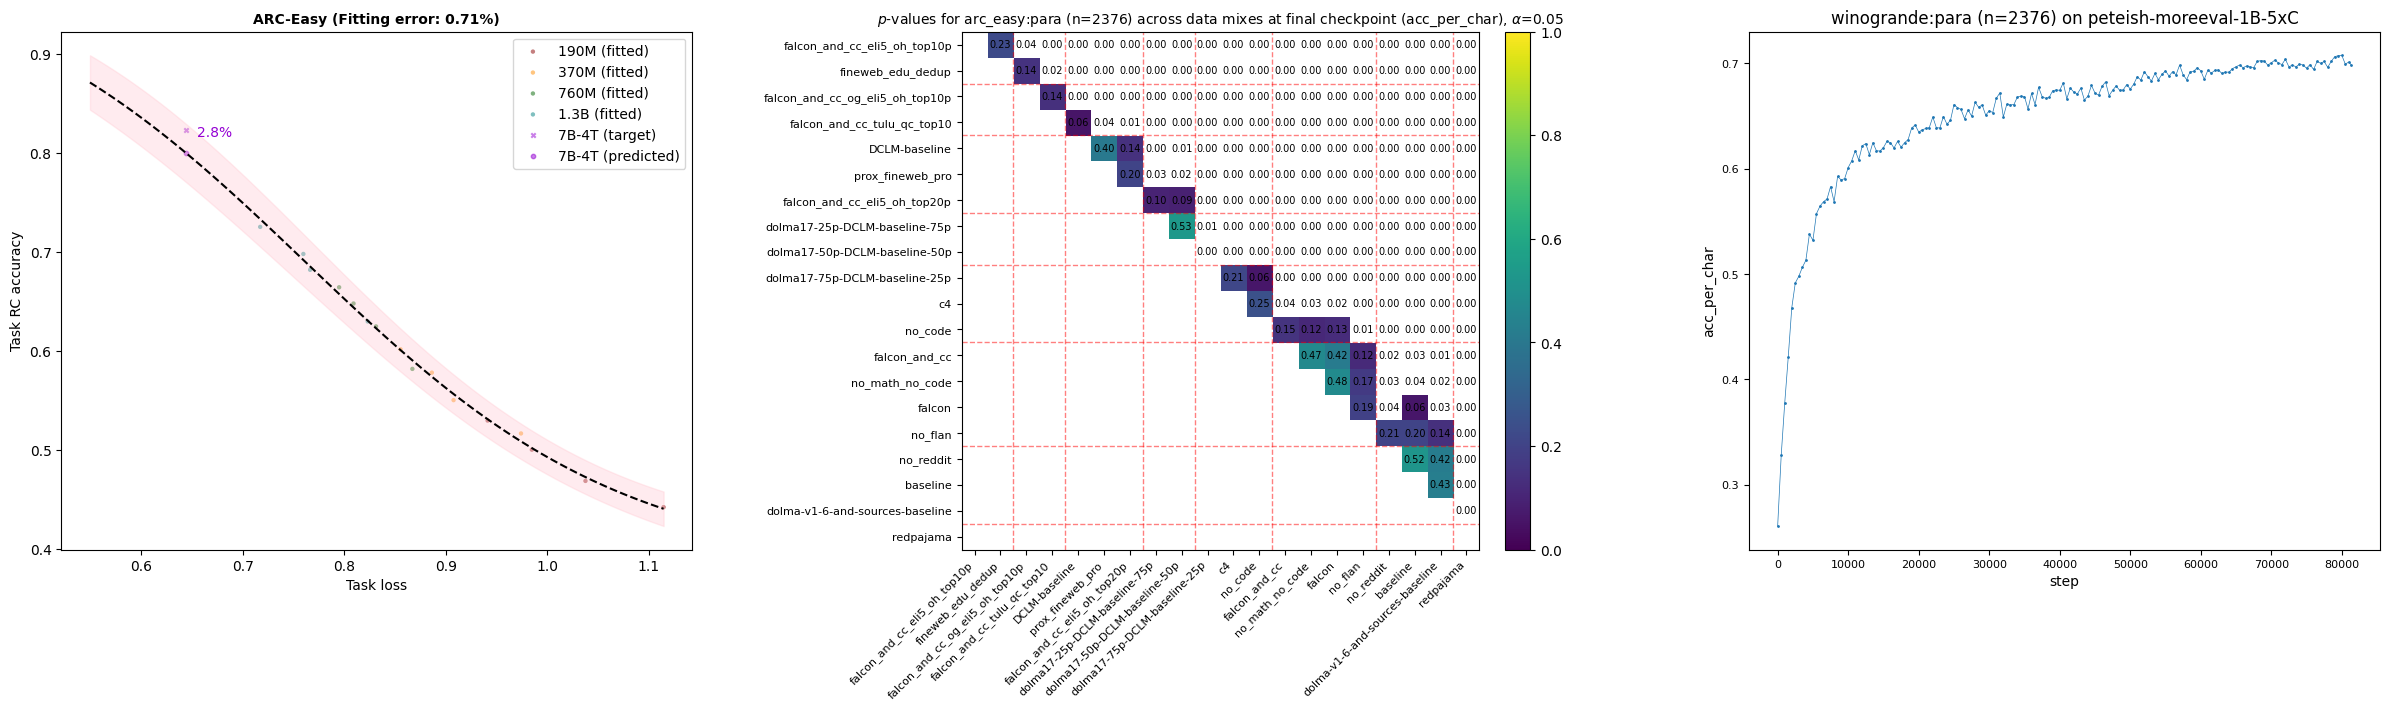

In [26]:
_ = plot_all_measures('arc_easy')
_ = plot_all_measures('arc_easy:enlarge')
_ = plot_all_measures('arc_easy:distractors')
_ = plot_all_measures('arc_easy:para')

In [27]:
# TODO: Use bootstrap sampling to see how these numbers change as we increase sample size

### Under Development: Step 1 Predictions

In [28]:
from olmo.scaling.scaling_laws.utils import get_final_configs, get_step2_data_by_name, get_task_sets
from scaling.step2 import main as step2_main
from scaling.step2 import fit_step2, predict_step2, plot_step2

os.chdir('/Users/dhei/ai2/new-evals/olmo-repos/OLMo')

config_path = "scripts/scaling/final.json"
# config_path = "scripts/scaling/final_7b_only.json"

configs = get_final_configs(config_path)
task_names = get_task_sets(["v2_main_variance"])

data_by_name = get_step2_data_by_name(
    configs,
    'arc_easy_test_5shot',
    x_metric='rc_bpb',
    y_metric='rc_acc',
    moving_avg=5,
    skip_perc=0.1,
)

coefficients, cov = fit_step2(data_by_name, 'arc_easy_test_5shot', 'rc_acc', use_log_sigmoid=False)

(
    predicted_data_by_name, plotted_predicted_data,
    (y, y_pred, rel_error, delta_error), all_rel_errors,
) = predict_step2(
    configs, data_by_name, coefficients, cov, y_metric='rc_acc', use_log_sigmoid=False
)

plt.close()
print(rel_error)

-0.06003510757433322


In [29]:
# xs - task loss
# ys - task accuracy
# ds - tokens (step 1) -- can take from wandb logs processed by olmo script (for Ian's project I'd can hook up the same script to extract wandb info)
# ns - params (step 1) -- can extract from config file
# ls - labels (step 1)
# mode - train/eval

In [30]:
# TODO:
    # Implement step 1 / stacked prediction
    # Add C4 loss from wandb logs to ladder models